# 1.9 Procesamiento de Lenguaje Natural con TensorFlow / Keras

Este notebook cubre NLP desde sus fundamentos estadisticos hasta la arquitectura Transformer, implementando cada concepto desde cero en TensorFlow/Keras para que la matematica sea visible en el codigo.

---

## Contenidos

1. Tokenizacion y vocabulario
2. Modelos de lenguaje n-grama
3. Word Embeddings: Skip-gram con Negative Sampling
4. Modelos recurrentes: RNN, LSTM, GRU
5. Mecanismo de atencion de Bahdanau
6. Transformer desde cero
7. Generacion de texto controlada
8. Metricas: perplejidad y BLEU

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.decomposition import PCA
import math, re, random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---

## 1. Tokenizacion y Vocabulario

Un vocabulario $\mathcal{V}$ es un conjunto finito de tokens. Un texto de longitud $T$ es:

$$\mathbf{x} = (x_1, x_2, \ldots, x_T), \quad x_t \in \mathcal{V}$$

El mapa $\text{stoi}: \mathcal{V} \to \{0, 1, \ldots, |\mathcal{V}|-1\}$ convierte tokens en indices.

Vocabulario: 262 tokens
Corpus     : 507 tokens
Tokens especiales: ['<PAD>', '<UNK>', '<BOS>', '<EOS>']


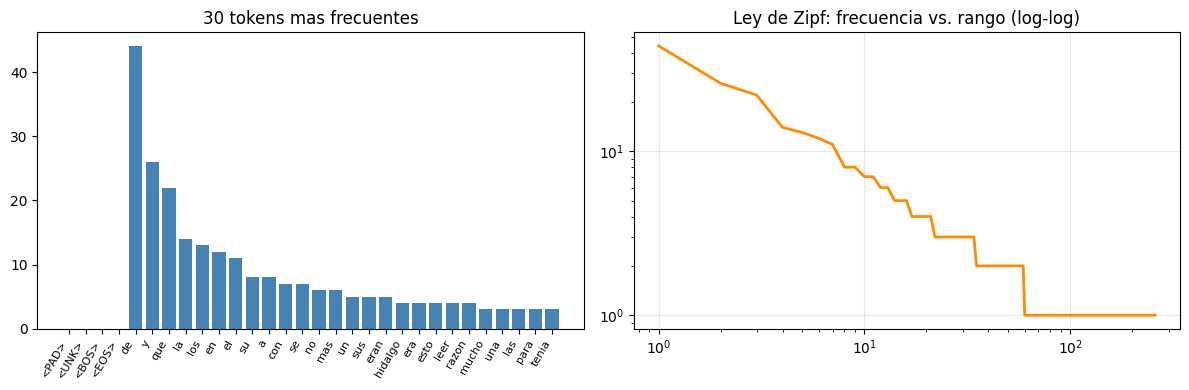

In [ ]:
CORPUS_RAW = """
En un lugar de la Mancha de cuyo nombre no quiero acordarme no ha mucho
tiempo que vivia un hidalgo de los de lanza en astillero adarga antigua
rocin flaco y galgo corredor una olla de algo mas vaca que carnero salpicon
las mas noches duelos y quebrantos los sabados lentejas los viernes algun
palomino de anadidura los domingos consumian las tres partes de su hacienda
el resto della concluian sayo de velarte calzas de velludo para las fiestas
con sus pantuflos de lo mismo y los dias de entresemana se honraba con su
vellori de lo mas fino tenia en su casa una ama que pasaba de los cuarenta
y una sobrina que no llegaba a los veinte y un mozo de campo y plaza que
asi ensillaba el rocin como tomaba la podadera frisaba la edad de nuestro
hidalgo con los cincuenta anos era de complexion recia seco de carnes enjuto
de rostro gran madrugador y amigo de la caza quieren decir que tenia el
sobrenombre de quijada o quesada que en esto hay alguna diferencia en los
autores que deste caso escriben aunque por conjeturas verisimiles se deja
entender que se llamaba quijana pero esto importa poco a nuestro cuento
basta que en la narracion del no se salga un punto de la verdad es pues de
saber que este sobredicho hidalgo los ratos que estaba ocioso que eran los
mas del ano se daba a leer libros de caballerias con tanta aficion y gusto
que olvido casi de todo punto el ejercicio de la caza y aun la administracion
de su hacienda y llego a tanto su curiosidad y desatino en esto que vendio
muchas hanegas de tierra de sembradura para comprar libros de caballerias
en que leer y asi llevo a su casa todos cuantos pudo haber dellos y de todos
ningunos le parecian tan bien como los que compuso el famoso feliciano de
silva porque la claridad de su prosa y aquellas entricadas razones suyas le
parecian de perlas y mas cuando llegaba a leer aquellos requiebros y cartas
de desafios donde en muchas partes hallaba escrito la razon de la sinrazon
que a mi razon se hace de tal manera mi razon enflaquece que con razon me
quejo de la vuestra fermosura y tambien cuando leia aquel gran caballero
era valiente y sus hazanas eran grandes sus amores eran puros su trato era
cortesano sus palabras eran honestas y sus obras eran muchas dormia poco
y leia mucho y con el poco dormir y el mucho leer se le seco el celebro
de manera que vino a perder el juicio lleno la fantasia de todo aquello que
leia en los libros asi de encantamentos como de pendencias batallas desafios
heridas requiebros amores tormentas y disparates imposibles y asentosele
de tal modo en la imaginacion que era verdad toda aquella maquina de aquellas
sonadas sonadisimas aventuras para el no habia otra historia mas cierta en
el mundo y con esto y siendo un hidalgo pobre no tenia otra manera de vivir"""


class Tokenizer:
    """
    Tokenizador word-level con tokens especiales.

    Tokens especiales:
    - <PAD> (0): relleno para alinear secuencias.
    - <UNK> (1): tokens fuera del vocabulario.
    - <BOS> (2): inicio de secuencia.
    - <EOS> (3): fin de secuencia.
    """

    PAD, UNK, BOS, EOS = '<PAD>', '<UNK>', '<BOS>', '<EOS>'
    SPECIAL = [PAD, UNK, BOS, EOS]

    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.stoi = {}
        self.itos = []

    def fit(self, texts):
        self.itos = list(self.SPECIAL)
        counts = Counter()
        for text in texts:
            counts.update(self._tokenize_raw(text))
        for tok, freq in counts.most_common():
            if freq >= self.min_freq:
                self.itos.append(tok)
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}
        return self

    def _tokenize_raw(self, text):
        return re.findall(r'[a-záéíóúñü]+', text.lower())

    def encode(self, text, add_special=True):
        tokens = self._tokenize_raw(text)
        ids    = [self.stoi.get(t, self.stoi[self.UNK]) for t in tokens]
        if add_special:
            return [self.stoi[self.BOS]] + ids + [self.stoi[self.EOS]]
        return ids

    def decode(self, ids, skip_special=True):
        tokens = [self.itos[i] for i in ids]
        if skip_special:
            tokens = [t for t in tokens if t not in self.SPECIAL]
        return ' '.join(tokens)

    def __len__(self):
        return len(self.itos)


tokenizer = Tokenizer(min_freq=1)
tokenizer.fit([CORPUS_RAW])

CORPUS_IDS = tokenizer.encode(CORPUS_RAW, add_special=False)
VOCAB_SIZE  = len(tokenizer)

print(f'Vocabulario: {VOCAB_SIZE} tokens')
print(f'Corpus     : {len(CORPUS_IDS)} tokens')
print(f'Tokens especiales: {tokenizer.SPECIAL}')

# Distribucion de frecuencias y Ley de Zipf
freq          = Counter(CORPUS_IDS)
freqs_sorted  = sorted(freq.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(min(30, VOCAB_SIZE)),
            [freq[i] for i in range(min(30, VOCAB_SIZE))], color='steelblue')
axes[0].set_xticks(range(min(30, VOCAB_SIZE)))
axes[0].set_xticklabels([tokenizer.itos[i] for i in range(min(30, VOCAB_SIZE))],
                         rotation=60, ha='right', fontsize=8)
axes[0].set_title('30 tokens mas frecuentes')

axes[1].plot(range(1, len(freqs_sorted)+1), freqs_sorted, color='darkorange', lw=2)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('Ley de Zipf: frecuencia vs. rango (log-log)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 2. Modelos de Lenguaje N-grama

Aproximacion de Markov de orden $n-1$:

$$p(x_t \mid x_{<t}) \approx p(x_t \mid x_{t-n+1}, \ldots, x_{t-1})$$

Estimacion con suavizado de Laplace:

$$\hat{p}(x_t \mid \text{contexto}) = \frac{C(\text{contexto}, x_t) + \alpha}{C(\text{contexto}) + \alpha \cdot |\mathcal{V}|}$$

Perplejidad:

$$\text{PPL} = \exp\!\left(-\frac{1}{T}\sum_{t=1}^{T} \log p(x_t \mid x_{<t})\right)$$

Perplejidad bigrama  : 28.2
Perplejidad trigrama : 24.7


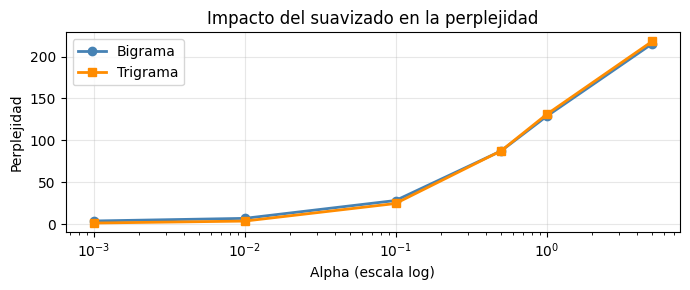

  Bigrama T=0.5: en un lugar leer trato salga honraba con el no aquella obras deja la imaginacion feliciano de la
  Bigrama T=1.0: en un lugar partes antigua amigo entresemana ha cuento leia cuyo viernes sobrina razones parecian sobrenombre entender que
  Trigrama T=0.5: en un lugar pasaba nuestro un imaginacion sonadas sinrazon olla mucho tanto veinte como enjuto en aquello quiero
  Trigrama T=1.0: en un lugar tanta vaca quijada deste del aventuras razones asentosele perder cuento batallas leer caballerias su duelos


In [ ]:
class NgramLM:
    """
    Modelo n-grama con suavizado de Laplace.
    Almacena conteos en tablas hash (defaultdict) para eficiencia.
    """

    def __init__(self, n=2, alpha=0.1):
        self.n       = n
        self.alpha   = alpha
        self.ngram_counts   = defaultdict(int)
        self.context_counts = defaultdict(int)
        self.vocab_size     = 0

    def fit(self, token_ids, vocab_size):
        self.vocab_size = vocab_size
        for i in range(len(token_ids) - self.n + 1):
            ngram   = tuple(token_ids[i : i + self.n])
            context = ngram[:-1]
            self.ngram_counts[(context, ngram[-1])] += 1
            self.context_counts[context] += 1
        return self

    def prob(self, token_id, context_ids):
        """p_Laplace(token | contexto) = (C + alpha) / (C_ctx + alpha * V)"""
        context = tuple(context_ids[-(self.n-1):])
        num     = self.ngram_counts[(context, token_id)] + self.alpha
        den     = self.context_counts[context] + self.alpha * self.vocab_size
        return num / den

    def perplexity(self, token_ids):
        """PPL = exp(-1/T * sum log p(x_t | contexto))"""
        log_prob, T = 0.0, 0
        for t in range(self.n - 1, len(token_ids)):
            log_prob += math.log(self.prob(token_ids[t], token_ids[t-(self.n-1):t]))
            T += 1
        return math.exp(-log_prob / T)

    def generate(self, seed_ids, n_tokens=20, temperature=1.0):
        """Generacion por muestreo con temperatura."""
        ids = list(seed_ids)
        for _ in range(n_tokens):
            context = tuple(ids[-(self.n-1):])
            probs   = np.array([
                self.ngram_counts.get((context, v), 0) + self.alpha
                for v in range(self.vocab_size)
            ], dtype=float)
            logits  = np.log(probs) / temperature
            logits -= logits.max()
            probs   = np.exp(logits)
            probs  /= probs.sum()
            ids.append(np.random.choice(self.vocab_size, p=probs))
        return ids


bigram_lm  = NgramLM(n=2, alpha=0.1).fit(CORPUS_IDS, VOCAB_SIZE)
trigram_lm = NgramLM(n=3, alpha=0.1).fit(CORPUS_IDS, VOCAB_SIZE)

print(f'Perplejidad bigrama  : {bigram_lm.perplexity(CORPUS_IDS):.1f}')
print(f'Perplejidad trigrama : {trigram_lm.perplexity(CORPUS_IDS):.1f}')

# Efecto del suavizado alpha
alphas   = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
ppls_bi  = [NgramLM(n=2, alpha=a).fit(CORPUS_IDS, VOCAB_SIZE).perplexity(CORPUS_IDS) for a in alphas]
ppls_tri = [NgramLM(n=3, alpha=a).fit(CORPUS_IDS, VOCAB_SIZE).perplexity(CORPUS_IDS) for a in alphas]

plt.figure(figsize=(7, 3))
plt.plot(alphas, ppls_bi,  label='Bigrama',  marker='o', color='steelblue',  lw=2)
plt.plot(alphas, ppls_tri, label='Trigrama', marker='s', color='darkorange', lw=2)
plt.xscale('log')
plt.xlabel('Alpha (escala log)'); plt.ylabel('Perplejidad')
plt.title('Impacto del suavizado en la perplejidad')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Generacion de texto
seed_ids = tokenizer.encode('en un lugar', add_special=False)
for model, name in [(bigram_lm, 'Bigrama'), (trigram_lm, 'Trigrama')]:
    for temp in [0.5, 1.0]:
        gen = model.generate(seed_ids, n_tokens=15, temperature=temp)
        print(f'  {name} T={temp}: {tokenizer.decode(gen)}')

---

## 3. Word Embeddings: Skip-gram con Negative Sampling

Dado el token central $x_t$, predecir tokens en la ventana $[-C,+C]$:

$$\mathcal{L}_{NS} = \log \sigma(\mathbf{u}_{pos}^\top \mathbf{v}_{central}) + \sum_{k=1}^{K} \mathbb{E}_{w_k \sim p_n}[\log \sigma(-\mathbf{u}_{w_k}^\top \mathbf{v}_{central})]$$

La distribucion de ruido $p_n(w) \propto f(w)^{3/4}$ suaviza la frecuencia para muestrear mas los tokens raros.

In [ ]:
def construir_pares_skipgram(token_ids, vocab_size, window=2, n_neg=5):
    """
    Genera arrays de pares (central, positivo, negativos[n_neg]).

    Distribucion de muestreo negativo: p_n(w) proporcional a freq(w)^0.75.
    El exponente 0.75 suaviza la distribucion: los tokens raros se muestrean
    mas que con la frecuencia pura, mejorando los embeddings de palabras raras.
    """
    centrales, positivos, negativos_list = [], [], []

    for t in range(len(token_ids)):
        for j in range(max(0, t-window), min(len(token_ids), t+window+1)):
            if j != t:
                centrales.append(token_ids[t])
                positivos.append(token_ids[j])

    # Tabla de muestreo negativo
    counts = Counter(token_ids)
    freqs  = np.array([counts.get(w, 0)**0.75 for w in range(vocab_size)], dtype=float)
    freqs /= freqs.sum()

    pos_set = set(zip(centrales, positivos))
    neg_mat = []
    for c, p in zip(centrales, positivos):
        negs = []
        while len(negs) < n_neg:
            w = np.random.choice(vocab_size, p=freqs)
            if w != p and w != c:
                negs.append(w)
        neg_mat.append(negs)

    return (np.array(centrales), np.array(positivos), np.array(neg_mat))


EMBED_DIM  = 50
N_NEG      = 5
BATCH_SG   = 256

print('Generando pares Skip-gram...')
centrales, positivos, neg_mat = construir_pares_skipgram(
    CORPUS_IDS, VOCAB_SIZE, window=3, n_neg=N_NEG
)
print(f'Pares positivos: {len(centrales):,}')

# Dataset de TensorFlow: mas eficiente que iterar en Python puro
# from_tensor_slices crea un dataset a partir de arrays numpy
# shuffle + batch + prefetch es el patron estandar para pipelines eficientes
sg_ds = (
    tf.data.Dataset.from_tensor_slices((centrales, positivos, neg_mat))
    .shuffle(10000)
    .batch(BATCH_SG, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)   # pre-carga el siguiente batch mientras se procesa el actual
)

Generando pares Skip-gram...
Pares positivos: 3,030


Epoca  10/50  Loss NS: 1.9372
Epoca  20/50  Loss NS: 1.1546
Epoca  30/50  Loss NS: 1.0127
Epoca  40/50  Loss NS: 0.9921
Epoca  50/50  Loss NS: 0.9659


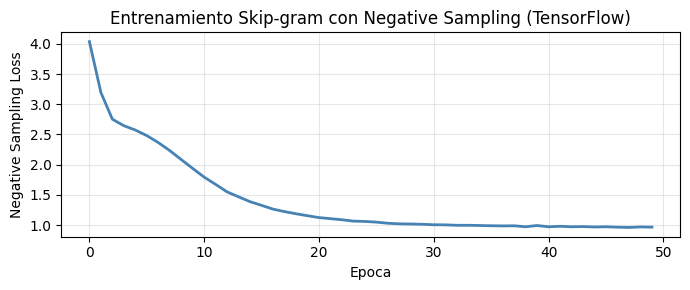

In [ ]:
class SkipGramNS(keras.Model):
    """
    Skip-gram con Negative Sampling implementado como subclase de keras.Model.

    Dos tablas de embeddings:
    - embeddings_v: representaciones de tokens centrales.
    - embeddings_u: representaciones de tokens de contexto.

    La perdida de negative sampling por batch:
    L = -mean[ log sigma(u_pos . v_c) + sum_k log sigma(-u_neg_k . v_c) ]

    En TF se implementa con tf.linalg.einsum o matmul para eficiencia.
    """

    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        # Inicializacion uniforme en [-0.5/d, 0.5/d] como en el paper original
        init = keras.initializers.RandomUniform(-0.5/embed_dim, 0.5/embed_dim)
        self.embeddings_v = layers.Embedding(vocab_size, embed_dim, embeddings_initializer=init)
        self.embeddings_u = layers.Embedding(vocab_size, embed_dim, embeddings_initializer='zeros')

    def call(self, central, positivo, negativos):
        """
        central   : (B,)     indices de tokens centrales
        positivo  : (B,)     indices de tokens de contexto positivos
        negativos : (B, K)   indices de tokens negativos

        Retorna la perdida de negative sampling.
        """
        v_c = self.embeddings_v(central)     # (B, D)
        u_p = self.embeddings_u(positivo)    # (B, D)
        u_n = self.embeddings_u(negativos)   # (B, K, D)

        # Score positivo: producto punto elemento a elemento, luego suma por dimension D
        # tf.reduce_sum(v_c * u_p, axis=1) equivale a dot(v_c[i], u_p[i]) por elemento del batch
        pos_score = tf.reduce_sum(v_c * u_p, axis=1)              # (B,)
        pos_loss  = tf.math.log_sigmoid(pos_score)                 # log sigma(u_p . v_c)

        # Score negativo: v_c se expande a (B, 1, D) para broadcasting
        # tf.einsum('bi,bki->bk'): producto punto de v_c con cada u_neg_k
        neg_score = tf.einsum('bi,bki->bk', v_c, u_n)             # (B, K)
        neg_loss  = tf.reduce_sum(tf.math.log_sigmoid(-neg_score), axis=1)  # (B,)

        return -tf.reduce_mean(pos_loss + neg_loss)


# Entrenamiento con tf.GradientTape
# GradientTape es el mecanismo de TF para diferenciacion automatica.
# Dentro del bloque 'with tape:', todas las operaciones sobre variables
# trainables quedan registradas para calcular gradientes despues.

model_sg = SkipGramNS(VOCAB_SIZE, EMBED_DIM)
opt_sg   = keras.optimizers.Adam(learning_rate=0.01)

EPOCHS_SG = 50
losses_sg = []

for epoch in range(1, EPOCHS_SG + 1):
    total = 0.0
    n_batches = 0
    for c_batch, p_batch, n_batch in sg_ds:
        with tf.GradientTape() as tape:
            # Calcular la perdida dentro del bloque tape para que se registren los gradientes
            loss = model_sg(c_batch, p_batch, n_batch)
        # Calcular los gradientes de la perdida respecto a los parametros entrenables
        grads = tape.gradient(loss, model_sg.trainable_variables)
        # Aplicar los gradientes al optimizador (actualizar los pesos)
        opt_sg.apply_gradients(zip(grads, model_sg.trainable_variables))
        total     += float(loss)
        n_batches += 1

    avg = total / n_batches
    losses_sg.append(avg)
    if epoch % 10 == 0:
        print(f'Epoca {epoch:3d}/{EPOCHS_SG}  Loss NS: {avg:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(losses_sg, color='steelblue', lw=2)
plt.xlabel('Epoca'); plt.ylabel('Negative Sampling Loss')
plt.title('Entrenamiento Skip-gram con Negative Sampling (TensorFlow)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

  Similares a "hidalgo": [('sobredicho', 0.7417281866073608), ('pobre', 0.6348292827606201), ('este', 0.6330704689025879), ('decir', 0.6170777678489685)]
  Similares a "caballero": [('valiente', 0.7911273837089539), ('gran', 0.7718731760978699), ('aquel', 0.7606392502784729), ('rostro', 0.6981013417243958)]
  Similares a "de": [('sembradura', 0.5764439702033997), ('porque', 0.5473458170890808), ('carnes', 0.546890139579773), ('comprar', 0.51231849193573)]


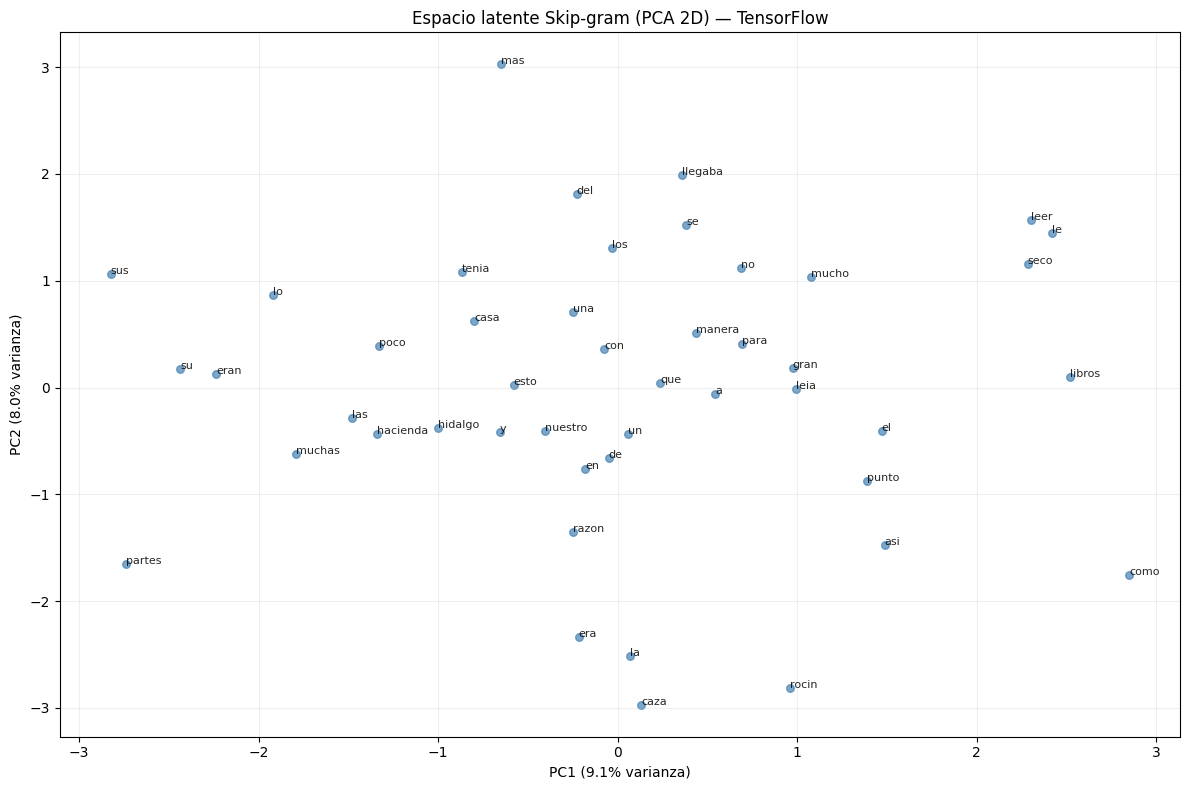

In [ ]:
def most_similar(word, model, tokenizer, top_k=5):
    """
    Encuentra los tokens mas similares por similitud coseno.
    sim(v_i, v_j) = v_i . v_j / (||v_i|| ||v_j||)
    """
    idx = tokenizer.stoi.get(word, 1)
    # .numpy() convierte el tensor de TF a array numpy
    W   = model.embeddings_v.embeddings.numpy()    # (V, D)
    v   = W[idx]

    # Normalizar por norma L2 para calcular coseno eficientemente con matmul
    norms  = np.linalg.norm(W, axis=1, keepdims=True) + 1e-8
    W_norm = W / norms
    v_norm = v / (np.linalg.norm(v) + 1e-8)
    sims   = W_norm @ v_norm                       # coseno con todos los vectores

    sims[idx] = -1.0
    sims[:4]  = -1.0   # excluir especiales
    top_idx   = np.argsort(sims)[::-1][:top_k]
    return [(tokenizer.itos[i], float(sims[i])) for i in top_idx]


for word in ['hidalgo', 'caballero', 'libro', 'de']:
    if word in tokenizer.stoi:
        sims = most_similar(word, model_sg, tokenizer, top_k=4)
        print(f'  Similares a "{word}": {sims}')

# Visualizar espacio latente con PCA
top_idx  = list(range(4, min(50, VOCAB_SIZE)))
W        = model_sg.embeddings_v.embeddings.numpy()[top_idx]
pca      = PCA(n_components=2)
W_2d     = pca.fit_transform(W)
var      = pca.explained_variance_ratio_

fig, ax  = plt.subplots(figsize=(12, 8))
ax.scatter(W_2d[:, 0], W_2d[:, 1], s=30, alpha=0.7, color='steelblue')
for i, idx in enumerate(top_idx):
    ax.annotate(tokenizer.itos[idx], (W_2d[i, 0], W_2d[i, 1]), fontsize=8, alpha=0.85)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% varianza)')
ax.set_title('Espacio latente Skip-gram (PCA 2D) — TensorFlow')
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

---

## 4. Modelos Recurrentes: RNN, LSTM y GRU

**RNN vanilla:**
$$\mathbf{h}_t = \tanh(\mathbf{W}_h \mathbf{h}_{t-1} + \mathbf{W}_x \mathbf{x}_t + \mathbf{b})$$

**LSTM — actualizacion aditiva de la celda (evita gradiente que desaparece):**
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t, \quad
\frac{\partial \mathbf{c}_t}{\partial \mathbf{c}_{t-1}} = \text{diag}(\mathbf{f}_t) \approx \mathbf{I} \text{ si } \mathbf{f}_t \approx 1$$

**GRU — dos compuertas en lugar de cuatro:**
$$\mathbf{h}_t = (1 - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \tilde{\mathbf{h}}_t$$

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.decomposition import PCA
import math, re, random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

# DATASET PARA MODELADO DE LENGUAJE
# Ventana deslizante: x = tokens[t:t+L], y = tokens[t+1:t+L+1]
# El modelo aprende a predecir el siguiente token en cada posicion.

SEQ_LEN    = 20
BATCH_SIZE = 32

def crear_lm_dataset(token_ids, seq_len, batch_size):
    """
    Crea un tf.data.Dataset de pares (x, y) para modelado de lenguaje.
    x = token_ids[i:i+seq_len]
    y = token_ids[i+1:i+seq_len+1]  (desplazado un paso)

    window() crea ventanas deslizantes de forma eficiente en TF.
    """
    data = tf.constant(token_ids, dtype=tf.int32)
    ds   = tf.data.Dataset.from_tensor_slices(data)
    # window(seq_len+1): cada ventana tiene seq_len+1 tokens (x e y juntos)
    # shift=1: desplazar la ventana 1 token a la vez
    ds   = ds.window(seq_len + 1, shift=1, drop_remainder=True)
    # flat_map: convertir cada ventana (un Dataset) a un tensor
    ds   = ds.flat_map(lambda w: w.batch(seq_len + 1))
    # Separar x (todos menos el ultimo) e y (todos menos el primero)
    ds   = ds.map(lambda s: (s[:-1], s[1:]))
    ds   = ds.shuffle(1000).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    return ds


lm_ds = crear_lm_dataset(CORPUS_IDS, SEQ_LEN, BATCH_SIZE).repeat()

x_demo, y_demo = next(iter(lm_ds))
print(f'Batch x: {x_demo.shape}  (B, T)')
print(f'Batch y: {y_demo.shape}  (B, T)')
print(f'Primer ejemplo x: {tokenizer.decode(x_demo[0].numpy().tolist())}')
print(f'Primer ejemplo y: {tokenizer.decode(y_demo[0].numpy().tolist())}')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Batch x: (32, 20)  (B, T)
Batch y: (32, 20)  (B, T)
Primer ejemplo x: casa una ama que pasaba de los cuarenta y una sobrina que no llegaba a los veinte y un mozo
Primer ejemplo y: una ama que pasaba de los cuarenta y una sobrina que no llegaba a los veinte y un mozo de


In [12]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

def construir_modelo_recurrente(vocab_size, embed_dim, hidden_dim,
                                n_layers=2, cell_type='LSTM', dropout=0.2):
    """
    Modelo de lenguaje recurrente optimizado con la API Funcional de Keras.
    """
    inp = keras.Input(shape=(None,), dtype=tf.int32)

    # Se retira mask_zero=True para no romper la aceleración de CuDNN en GPU.
    # Si las secuencias ya tienen el mismo tamaño (pad/truncate), la máscara no es estrictamente necesaria.
    x = layers.Embedding(vocab_size, embed_dim)(inp)
    x = layers.Dropout(dropout)(x)

    # Construcción de capas recurrentes
    for i in range(n_layers):
        is_last = (i == n_layers - 1)
        # Aplicamos dropout solo si no es la última capa, utilizando el argumento interno de la celda.
        # Se elimina la capa explícita layers.Dropout(dropout)(x) posterior para evitar doble penalización.
        drop_rate = dropout if not is_last else 0.0

        if cell_type == 'LSTM':
            x = layers.LSTM(hidden_dim, return_sequences=True, dropout=drop_rate)(x)
        elif cell_type == 'GRU':
            x = layers.GRU(hidden_dim, return_sequences=True, dropout=drop_rate)(x)
        elif cell_type == 'RNN':
            x = layers.SimpleRNN(hidden_dim, return_sequences=True, dropout=drop_rate)(x)

    # Cabeza de predicción
    out = layers.Dense(vocab_size)(x)

    return keras.Model(inp, out)

def calcular_perplejidad_tf(modelo, token_ids, seq_len=50):
    """Calcula la perplejidad del modelo sobre una secuencia."""
    x_arr = np.array(token_ids[:-1])[np.newaxis, :seq_len]   # (1, T)
    y_arr = np.array(token_ids[1:])[:seq_len]                # (T,)

    logits = modelo(x_arr, training=False)                   # (1, T, V)
    logits = tf.squeeze(logits, axis=0)                      # (T, V)

    loss = keras.losses.sparse_categorical_crossentropy(
        y_arr, logits, from_logits=True
    )
    return float(tf.exp(tf.reduce_mean(loss)))

# ==========================================
# Configuración y Entrenamiento
# ==========================================
# Variables de ejemplo (asegúrate de definirlas en tu entorno)
# VOCAB_SIZE = 10000
# lm_ds = ... (tu tf.data.Dataset)
# CORPUS_IDS = ... (tu lista de enteros)

EMBED_DIM_LM = 64
HIDDEN_DIM   = 128
EPOCHS_LM    = 50

modelos_lm  = {}
historias   = {}

# Definir las celdas a entrenar
celdas_a_evaluar = ['RNN', 'GRU', 'LSTM']

for cell in celdas_a_evaluar:
    print(f'\nEntrenando arquitectura con celdas {cell}...')

    # Asumiendo que VOCAB_SIZE está definido globalmente en tu script
    m = construir_modelo_recurrente(VOCAB_SIZE, EMBED_DIM_LM, HIDDEN_DIM,
                                     n_layers=2, cell_type=cell)

    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    )

    hist = m.fit(
        lm_ds,
        epochs=EPOCHS_LM,
        verbose=1,
        callbacks=[
            keras.callbacks.LambdaCallback(
                on_epoch_end=lambda e, logs: print(
                    f'  Época {e+1:3d}/{EPOCHS_LM}  Loss: {logs["loss"]:.4f}  '
                    f'PPL: {math.exp(logs["loss"]):.1f}'
                ) if (e+1) % 10 == 0 else None
            )
        ]
    )

    modelos_lm[cell]  = m
    historias[cell]   = hist.history['loss']

# ==========================================
# Visualización
# ==========================================
colors = {'RNN': 'crimson', 'GRU': 'darkorange', 'LSTM': 'steelblue'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cell, losses in historias.items():
    axes[0].plot(losses, label=cell, color=colors[cell], lw=2)
    axes[1].plot([math.exp(l) for l in losses], label=cell, color=colors[cell], lw=2)

axes[0].set(title='Cross-Entropy Loss', xlabel='Época')
axes[1].set(title='Perplejidad', xlabel='Época')

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparativa RNN vs. GRU vs. LSTM — TensorFlow', fontsize=13)
plt.tight_layout()
plt.show()

print('\nPerplejidad final:')
for cell, m in modelos_lm.items():
    ppl = calcular_perplejidad_tf(m, CORPUS_IDS)
    params = m.count_params()
    print(f'  {cell:<5}: PPL={ppl:6.1f}  Params={params:,}')


Entrenando arquitectura con celdas RNN...
Epoch 1/50
  83932/Unknown 625s 7ms/step - loss: 0.1177

KeyboardInterrupt: 

In [13]:
def generar_rnn_tf(modelo, tokenizer, seed_text, n_tokens=25,
                   temperature=1.0, top_k=None):
    """
    Generacion autorregresiva con un modelo recurrente de Keras.

    Diferencia clave respecto a PyTorch:
    En Keras no hay estado oculto explicito en el modelo Sequential;
    se pasa la secuencia completa generada hasta el momento en cada paso.
    Para modelos estateful, usar stateful=True en las capas LSTM/GRU
    y llamar model.reset_states() entre secuencias.
    """
    ids = tokenizer.encode(seed_text, add_special=False)

    for _ in range(n_tokens):
        x      = np.array(ids)[np.newaxis, :]        # (1, T)
        logits = modelo(x, training=False)            # (1, T, V)
        logits = logits[0, -1, :].numpy()             # ultimo token: (V,)

        # Aplicar temperatura: dividir logits amplifica o suaviza diferencias
        logits = logits / max(temperature, 1e-8)

        if top_k is not None:
            # Mantener solo los top_k scores mas altos; el resto a -inf
            threshold = np.sort(logits)[-top_k]
            logits    = np.where(logits >= threshold, logits, -np.inf)

        # Softmax manual para convertir logits a probabilidades
        logits -= logits.max()   # estabilidad numerica: evitar overflow en exp()
        probs   = np.exp(logits)
        probs  /= probs.sum()

        next_id = np.random.choice(VOCAB_SIZE, p=probs)
        ids.append(next_id)

    return tokenizer.decode(ids)


seed = 'en un lugar'
print('Generacion de texto con modelos recurrentes (TF):')
print(f'Semilla: "{seed}"\n')
for cell, m in modelos_lm.items():
    gen = generar_rnn_tf(m, tokenizer, seed, n_tokens=20, temperature=0.8)
    print(f'  {cell:<5}: {gen}')

Generacion de texto con modelos recurrentes (TF):
Semilla: "en un lugar"



---

## 5. Mecanismo de Atencion de Bahdanau

Score de alineamiento:
$$e_{t,s} = \mathbf{v}_a^\top \tanh(\mathbf{W}_1 \mathbf{h}_s^{enc} + \mathbf{W}_2 \mathbf{h}_{t-1}^{dec})$$

Pesos de atencion:
$$\alpha_{t,s} = \frac{\exp(e_{t,s})}{\sum_{s'} \exp(e_{t,s'})}, \quad \sum_s \alpha_{t,s} = 1$$

Contexto dinamico:
$$\mathbf{c}_t = \sum_{s=1}^{T_x} \alpha_{t,s} \mathbf{h}_s^{enc}$$

Contexto : (1, 64)     (B, enc_dim)
Alphas   : (1, 12)  (B, T_x)
Suma alphas: 1.0000  (debe ser 1.0)


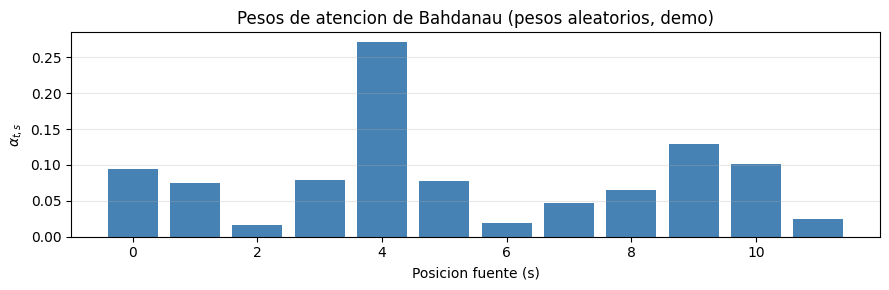

In [14]:
class BahdanauAttention(layers.Layer):
    """
    Atencion de Bahdanau implementada como capa de Keras.

    La herencia de layers.Layer permite integrarla en modelos de Keras
    y que sus variables sean entrenables automaticamente.

    Complejidad: O(T_x * T_y * attn_dim) donde attn_dim es la dimension
    de la proyeccion intermedia.
    """

    def __init__(self, attn_dim, **kwargs):
        super().__init__(**kwargs)
        # W1 proyecta los estados del encoder
        self.W1 = layers.Dense(attn_dim, use_bias=False)
        # W2 proyecta el estado del decoder
        self.W2 = layers.Dense(attn_dim, use_bias=False)
        # v produce el score escalar
        self.v  = layers.Dense(1,        use_bias=False)

    def call(self, enc_outputs, dec_hidden):
        """
        enc_outputs : (B, T_x, enc_dim)  estados del encoder
        dec_hidden  : (B, dec_dim)        estado del decoder en t-1

        Retorna:
        context     : (B, enc_dim)  vector de contexto c_t
        alphas      : (B, T_x)      pesos de atencion alpha_{t,s}
        """
        # Expandir dec_hidden a (B, 1, dec_dim) para sumar con (B, T_x, attn_dim)
        # El broadcasting se encarga de replicar el estado del decoder en T_x posiciones
        score = self.v(
            tf.nn.tanh(
                self.W1(enc_outputs) +             # (B, T_x, attn_dim)
                self.W2(tf.expand_dims(dec_hidden, 1))  # (B, 1, attn_dim) -> broadcast
            )
        )                                          # (B, T_x, 1)
        score   = tf.squeeze(score, axis=-1)       # (B, T_x)
        alphas  = tf.nn.softmax(score, axis=-1)    # (B, T_x)  suma = 1

        # Suma ponderada: multiplicar alphas por los estados del encoder
        # tf.expand_dims para hacer (B, T_x, 1) y multiplicar con (B, T_x, enc_dim)
        context = tf.reduce_sum(
            tf.expand_dims(alphas, -1) * enc_outputs,   # (B, T_x, enc_dim)
            axis=1                                        # reducir sobre T_x -> (B, enc_dim)
        )
        return context, alphas


# DEMO: verificar dimensiones y visualizar pesos de atencion
HIDDEN_ATT = 64
ATTN_DIM   = 32
T_x        = 12
B_demo     = 1

attn_demo   = BahdanauAttention(attn_dim=ATTN_DIM)
enc_out_d   = tf.random.normal((B_demo, T_x, HIDDEN_ATT))
dec_hid_d   = tf.random.normal((B_demo, HIDDEN_ATT))

ctx, alphas = attn_demo(enc_out_d, dec_hid_d)
print(f'Contexto : {ctx.shape}     (B, enc_dim)')
print(f'Alphas   : {alphas.shape}  (B, T_x)')
print(f'Suma alphas: {float(tf.reduce_sum(alphas)):.4f}  (debe ser 1.0)')

# Visualizar la distribucion de atencion
plt.figure(figsize=(9, 3))
plt.bar(range(T_x), alphas.numpy().squeeze(), color='steelblue')
plt.xlabel('Posicion fuente (s)')
plt.ylabel(r'$\alpha_{t,s}$')
plt.title('Pesos de atencion de Bahdanau (pesos aleatorios, demo)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---

## 6. Transformer desde Cero

**Scaled Dot-Product Attention** (dividir por $\sqrt{d_k}$ normaliza la varianza a 1):
$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$$

**Multi-Head Attention** ($h$ cabezas en paralelo):
$$\text{MHA}(X) = \text{Concat}(\text{head}_1,\ldots,\text{head}_h)W^O$$

**Codificacion posicional sinusoidal:**
$$\text{PE}_{(pos,2i)} = \sin(pos/10000^{2i/d}), \quad \text{PE}_{(pos,2i+1)} = \cos(pos/10000^{2i/d})$$

In [15]:
class PositionalEncoding(layers.Layer):
    """
    Codificacion posicional sinusoidal (Vaswani et al., 2017).

    Se registra como variable no entrenable (tf.constant o add_weight con
    trainable=False). Se suma a los embeddings de tokens antes de la primera capa.

    Propiedad: para cualquier offset k, PE_{pos+k} es una transformacion
    lineal de PE_{pos}, permitiendo al modelo aprender posiciones relativas.
    """

    def __init__(self, d_model, max_len=512, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dropout = layers.Dropout(dropout)

        # Precalcular la tabla de encodings
        pos = np.arange(max_len)[:, np.newaxis]           # (max_len, 1)
        i   = np.arange(0, d_model, 2)[np.newaxis, :]    # (1, d_model/2)
        # div_term: 10000^(2i/d_model) en forma logaritmica para estabilidad
        div = np.exp(i * (-np.log(10000.0) / d_model))

        pe = np.zeros((1, max_len, d_model), dtype=np.float32)
        pe[0, :, 0::2] = np.sin(pos * div)   # dimensiones pares
        pe[0, :, 1::2] = np.cos(pos * div)   # dimensiones impares

        # tf.constant: tensor no entrenable (no es una variable de TF)
        self.pe = tf.constant(pe, dtype=tf.float32)

    def call(self, x, training=False):
        """x: (B, T, d_model)"""
        # Sumar el encoding posicional a los embeddings de tokens
        # tf.shape(x)[1] da la longitud real de la secuencia en tiempo de ejecucion
        x = x + self.pe[:, :tf.shape(x)[1], :]
        return self.dropout(x, training=training)


class MultiHeadAttention(layers.Layer):
    """
    Multi-Head Self-Attention implementado desde cero.

    Las proyecciones W_Q, W_K, W_V, W_O se implementan como capas Dense.
    Las h cabezas se procesan en paralelo mediante reshape + transpose,
    sin bucles Python (mas eficiente en TF).

    Formas intermedias:
    Entrada : (B, T, d_model)
    Despues de proyeccion: (B, T, d_model) -> split a (B, h, T, d_k)
    Scores  : (B, h, T_q, T_k)
    Salida  : (B, T, d_model)
    """

    def __init__(self, d_model, n_heads, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        assert d_model % n_heads == 0
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_k      = d_model // n_heads

        self.W_Q = layers.Dense(d_model, use_bias=False)
        self.W_K = layers.Dense(d_model, use_bias=False)
        self.W_V = layers.Dense(d_model, use_bias=False)
        self.W_O = layers.Dense(d_model, use_bias=False)
        self.dropout = layers.Dropout(dropout)

    def split_heads(self, x):
        """(B, T, d_model) -> (B, h, T, d_k)"""
        B = tf.shape(x)[0]
        T = tf.shape(x)[1]
        # reshape y transpose para separar las cabezas
        x = tf.reshape(x, (B, T, self.n_heads, self.d_k))
        return tf.transpose(x, perm=[0, 2, 1, 3])   # (B, h, T, d_k)

    def call(self, query, key, value, mask=None, training=False):
        B = tf.shape(query)[0]

        Q = self.split_heads(self.W_Q(query))   # (B, h, T_q, d_k)
        K = self.split_heads(self.W_K(key))     # (B, h, T_k, d_k)
        V = self.split_heads(self.W_V(value))   # (B, h, T_k, d_k)

        # Scaled Dot-Product Attention
        # matmul entre (B,h,T_q,d_k) y (B,h,d_k,T_k) -> (B,h,T_q,T_k)
        scale  = tf.cast(self.d_k, tf.float32) ** 0.5
        scores = tf.matmul(Q, K, transpose_b=True) / scale  # (B, h, T_q, T_k)

        if mask is not None:
            # Sumar -1e9 (efectivamente -inf) donde mask=True para anular esas posiciones
            scores += mask * -1e9

        alphas = self.dropout(tf.nn.softmax(scores, axis=-1), training=training)
        out    = tf.matmul(alphas, V)            # (B, h, T_q, d_k)

        # Reunir cabezas: (B, h, T, d_k) -> (B, T, d_model)
        out = tf.transpose(out, perm=[0, 2, 1, 3])   # (B, T, h, d_k)
        out = tf.reshape(out, (B, -1, self.d_model))  # (B, T, d_model)
        return self.W_O(out), alphas


class FeedForward(layers.Layer):
    """
    Red Feed-Forward posicional con activacion GeLU.

    Aplica la misma transformacion a cada posicion de la secuencia.
    Los pesos se comparten entre posiciones (no entre capas del Transformer).
    d_ff = 4 * d_model es el factor de expansion del paper original.
    """

    def __init__(self, d_model, d_ff, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dense1  = layers.Dense(d_ff,    activation='gelu')   # GeLU: diferenciable en todo punto
        self.dense2  = layers.Dense(d_model)
        self.drop    = layers.Dropout(dropout)

    def call(self, x, training=False):
        return self.dense2(self.drop(self.dense1(x), training=training))


class TransformerBlock(layers.Layer):
    """
    Bloque Transformer con Pre-LayerNorm.

    Pre-LN (vs Post-LN del Transformer original):
    La LayerNorm se aplica ANTES de cada sub-capa, no despues.
    x_{l+1} = x_l + SubLayer(LN(x_l))

    Ventaja: gradientes mas estables, entrena sin warmup.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff    = FeedForward(d_model, d_ff, dropout)

    def call(self, x, mask=None, training=False):
        # Sub-capa 1: Self-Attention con conexion residual
        normed, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x),
                              mask=mask, training=training)
        x = x + normed
        # Sub-capa 2: Feed-Forward con conexion residual
        x = x + self.ff(self.norm2(x), training=training)
        return x


print('Capas del Transformer definidas.')

Capas del Transformer definidas.


In [16]:
class TransformerLM(keras.Model):
    """
    Modelo de lenguaje Transformer (estilo GPT) implementado en TF/Keras.

    Arquitectura:
    1. Embedding de tokens escalado por sqrt(d_model) (practica estandar).
    2. Codificacion posicional sinusoidal.
    3. L bloques Transformer con mascara causal.
    4. LayerNorm final (Pre-LN).
    5. Proyeccion lineal a vocab_size (logits).

    Mascara causal: garantiza que la posicion t solo atienda a posiciones <= t.
    Se implementa como una mascara triangular superior con -inf antes del softmax.
    """

    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff,
                 max_len=512, dropout=0.1):
        super().__init__()
        self.d_model   = d_model
        self.embedding = layers.Embedding(vocab_size, d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.blocks    = [TransformerBlock(d_model, n_heads, d_ff, dropout)
                          for _ in range(n_layers)]
        self.norm_out  = layers.LayerNormalization(epsilon=1e-6)
        self.head      = layers.Dense(vocab_size, use_bias=False)

    def _mascara_causal(self, T):
        """
        Genera la mascara triangular superior de forma (1, 1, T, T).
        Las posiciones con 1 seran bloqueadas (se suma -1e9 antes del softmax).

        La forma (1, 1, T, T) permite broadcasting con (B, h, T, T).
        """
        # tf.linalg.band_part: extrae triangulo superior
        # -band_part: invierte para obtener la parte superior excluido el diagonal
        mask = 1 - tf.linalg.band_part(tf.ones((T, T)), -1, 0)  # triangulo superior
        return tf.cast(mask[tf.newaxis, tf.newaxis, :, :], tf.float32)  # (1,1,T,T)

    def call(self, x, training=False):
        T    = tf.shape(x)[1]
        mask = self._mascara_causal(T)    # (1, 1, T, T)

        # Escalar embeddings por sqrt(d_model): hace que la norma del embedding
        # sea comparable a la del encoding posicional (evita que uno domine al otro)
        emb = self.embedding(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        emb = self.pos_enc(emb, training=training)

        for block in self.blocks:
            emb = block(emb, mask=mask, training=training)

        return self.head(self.norm_out(emb))  # (B, T, vocab_size)


# Verificar dimensiones
tf_test = TransformerLM(vocab_size=VOCAB_SIZE, d_model=64, n_heads=4,
                        n_layers=2, d_ff=256, max_len=SEQ_LEN+10)
x_test  = tf.zeros((2, SEQ_LEN), dtype=tf.int32)
out_t   = tf_test(x_test, training=False)
print(f'Entrada: {x_test.shape}')
print(f'Salida : {out_t.shape}   (B, T, V)')
print(f'Params : {tf_test.count_params():,}')
del tf_test, x_test, out_t

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_block' (of type TransformerBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention_1' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the 

Entrada: (2, 20)
Salida : (2, 20, 262)   (B, T, V)
Params : 133,120


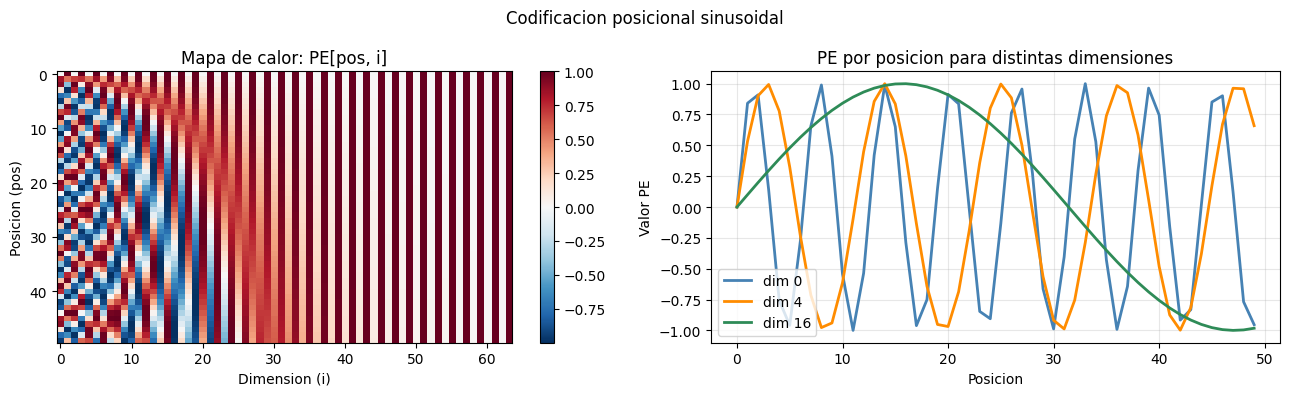

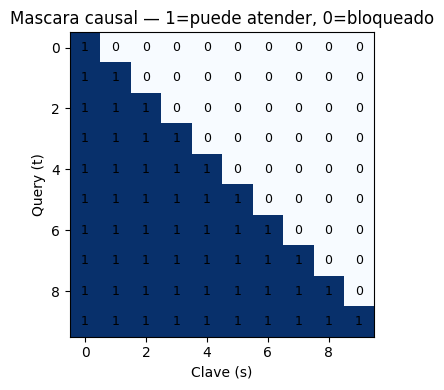

In [17]:
# Visualizar la codificacion posicional
pe_demo = PositionalEncoding(d_model=64, max_len=50, dropout=0.0)
x_zeros = tf.zeros((1, 50, 64))
pe_vals = pe_demo(x_zeros, training=False).numpy().squeeze()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(pe_vals, aspect='auto', cmap='RdBu_r', origin='upper')
plt.colorbar(im, ax=axes[0])
axes[0].set_xlabel('Dimension (i)'); axes[0].set_ylabel('Posicion (pos)')
axes[0].set_title('Mapa de calor: PE[pos, i]')

for i, c in [(0,'steelblue'),(4,'darkorange'),(16,'seagreen')]:
    axes[1].plot(pe_vals[:, i], label=f'dim {i}', color=c, lw=2)
axes[1].set(xlabel='Posicion', ylabel='Valor PE')
axes[1].set_title('PE por posicion para distintas dimensiones')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Codificacion posicional sinusoidal', fontsize=12)
plt.tight_layout(); plt.show()

# Visualizar la mascara causal
T_mask   = 10
tf_dummy = TransformerLM(10, 16, 2, 1, 32)
mask_vis = tf_dummy._mascara_causal(T_mask).numpy().squeeze()

plt.figure(figsize=(5, 4))
plt.imshow(1 - mask_vis, cmap='Blues', vmin=0, vmax=1)
plt.xlabel('Clave (s)'); plt.ylabel('Query (t)')
plt.title('Mascara causal — 1=puede atender, 0=bloqueado')
for i in range(T_mask):
    for j in range(T_mask):
        plt.text(j, i, str(int(1-mask_vis[i,j])), ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()
del tf_dummy

Entrenando Transformer LM (TensorFlow)...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention_9' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_block_9' (of type TransformerBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention_10' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see

15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4.9211
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.2989
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9932
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1874
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7048
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4321
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2861
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2231
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1809
Epoch 10/50
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1637
  [Resumen Epoca  10/50]  Loss: 0.1634  PPL: 1.2

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1634
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1473
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1350
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1267
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - l

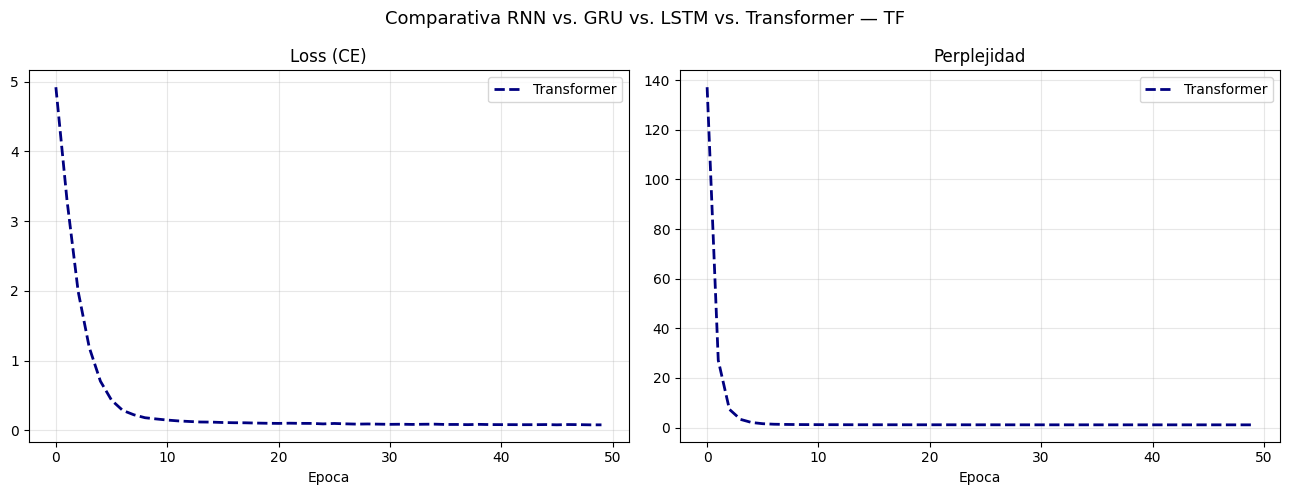


Perplejidad final en corpus:
Modelo               PPL      Params
--------------------------------------
Bigrama             28.2         N/A
Trigrama            24.7         N/A


InvalidArgumentError: Exception encountered when calling PositionalEncoding.call().

[1m{{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:AddV2] name: [0m

Arguments received by PositionalEncoding.call():
  • x=tf.Tensor(shape=(1, 50, 64), dtype=float32)
  • training=False

In [21]:
# Entrenar el Transformer LM
transformer_lm = TransformerLM(
    vocab_size = VOCAB_SIZE,
    d_model    = 64,
    n_heads    = 4,
    n_layers   = 2,
    d_ff       = 256,
    max_len    = SEQ_LEN + 10,
    dropout    = 0.1,
)

# 1. CORRECCIÓN DEL CUELLO DE BOTELLA: Obtener la cantidad de batches sin iterar el dataset
try:
    # Calculate steps per epoch based on the effective number of samples
    # (length of CORPUS_IDS - sequence length) divided by batch size.
    # This assumes `drop_remainder=True` in dataset creation.
    pasos_por_epoca = (len(CORPUS_IDS) - SEQ_LEN) // BATCH_SIZE

    # Guard against zero or negative steps in case of very small corpus
    if pasos_por_epoca <= 0:
        raise ValueError("Calculated steps per epoch is not positive. Check corpus size, sequence length, and batch size.")

except Exception as e:
    print(f"Error calculating pasos_por_epoca: {e}")
    # Fallback to manual calculation if an error occurs
    pasos_por_epoca = (len(CORPUS_IDS) - SEQ_LEN) // BATCH_SIZE
    if pasos_por_epoca <= 0:
        pasos_por_epoca = 1 # Ensure at least 1 step if all else fails, to prevent error

# Define EPOCHS_TF before it's used
EPOCHS_TF = 50

total_pasos = EPOCHS_TF * pasos_por_epoca

# CosineDecay
lr_sched = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-3,
    decay_steps=total_pasos,
    alpha=1e-4,
)

# AdamW
optimizer = keras.optimizers.AdamW(learning_rate=lr_sched, weight_decay=0.01)

transformer_lm.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
)

print('Entrenando Transformer LM (TensorFlow)...')

# 2. CORRECCIÓN DE VISIBILIDAD: verbose=1 para evitar la sensación de congelamiento
hist_tf = transformer_lm.fit(
    lm_ds,
    steps_per_epoch=pasos_por_epoca, # Specify steps_per_epoch for infinite dataset
    epochs=EPOCHS_TF,
    verbose=1,
    callbacks=[keras.callbacks.LambdaCallback(
        on_epoch_end=lambda e, logs: print(
            f'\n  [Resumen Epoca {e+1:3d}/{EPOCHS_TF}]  Loss: {logs["loss"]:.4f}  '
            f'PPL: {math.exp(logs["loss"]):.1f}\n'
        ) if (e+1) % 10 == 0 else None
    )]
)

# Comparativa final de perplejidad
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graficar RNN, GRU, LSTM (Asumiendo que 'historias' y 'colors' vienen de tu celda anterior)
for cell, losses in historias.items():
    axes[0].plot(losses, label=cell, color=colors[cell], lw=2)
    axes[1].plot([math.exp(l) for l in losses], label=cell, color=colors[cell], lw=2)

# Graficar Transformer
tf_losses = hist_tf.history['loss']
axes[0].plot(tf_losses,                         label='Transformer', color='navy', lw=2, ls='--')
axes[1].plot([math.exp(l) for l in tf_losses],  label='Transformer', color='navy', lw=2, ls='--')

axes[0].set(title='Loss (CE)', xlabel='Epoca')
axes[1].set(title='Perplejidad', xlabel='Epoca')

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparativa RNN vs. GRU vs. LSTM vs. Transformer — TF', fontsize=13)
plt.tight_layout()
plt.show()

# Métricas finales
print('\nPerplejidad final en corpus:')
print(f'{"Modelo":<15} {"PPL":>8}  {"Params":>10}')
print('-'*38)
# Asumiendo que bigram_lm y trigram_lm existen en tu entorno
print(f'{"Bigrama":<15} {bigram_lm.perplexity(CORPUS_IDS):>8.1f}  {"N/A":>10}')
print(f'{"Trigrama":<15} {trigram_lm.perplexity(CORPUS_IDS):>8.1f}  {"N/A":>10}')

for cell, m in modelos_lm.items():
    print(f'{cell:<15} {calcular_perplejidad_tf(m, CORPUS_IDS):>8.1f}  {m.count_params():>10,}')

print(f'{"Transformer":<15} {calcular_perplejidad_tf(transformer_lm, CORPUS_IDS):>8.1f}  {transformer_lm.count_params():>10,}')

---

## 7. Generacion de Texto Controlada

**Temperatura:** escala los logits antes del softmax.
$$p_\tau(x_t = w) = \frac{\exp(z_w/\tau)}{\sum_{w'} \exp(z_{w'}/\tau)}$$

**Top-k:** muestrear solo de los $k$ tokens mas probables.

**Nucleus (top-p):** muestrear del conjunto minimo con probabilidad acumulada $\geq p$.

In [22]:
def generar_transformer_tf(modelo, tokenizer, seed_text, n_tokens=30,
                            temperature=1.0, top_k=None, top_p=None):
    """
    Generacion autorregresiva con el Transformer de TF.

    En cada paso se reprocesa toda la secuencia generada (O(T^2) computo).
    Para produccion se usaria KV-Cache para reducir a O(T) por paso.

    Estrategias implementadas:
    1. Temperatura: suavizar (T>1) o agudizar (T<1) la distribucion.
    2. Top-k: filtrar todo fuera de los k candidatos mas probables.
    3. Nucleus (top-p): filtrar por probabilidad acumulada.
    Se pueden combinar: temperatura + top-k + top-p.
    """
    ids = tokenizer.encode(seed_text, add_special=False)

    for _ in range(n_tokens):
        x      = tf.constant([ids], dtype=tf.int32)      # (1, T)
        logits = modelo(x, training=False)                # (1, T, V)
        logits = logits[0, -1, :].numpy()                 # ultimo token: (V,)

        # 1. Temperatura
        logits = logits / max(temperature, 1e-8)

        # 2. Top-k: poner -inf a los tokens fuera del top-k
        if top_k is not None and top_k > 0:
            k_val     = min(top_k, len(logits))
            threshold = np.sort(logits)[-k_val]
            logits    = np.where(logits >= threshold, logits, -np.inf)

        # 3. Nucleus sampling (top-p): filtrar por probabilidad acumulada
        if top_p is not None and 0.0 < top_p < 1.0:
            sorted_idx    = np.argsort(logits)[::-1]   # orden descendente
            sorted_logits = logits[sorted_idx]
            # Probabilidades acumuladas del token mas probable hacia el menos probable
            sorted_probs  = np.exp(sorted_logits - sorted_logits.max())
            sorted_probs /= sorted_probs.sum()
            cumsum        = np.cumsum(sorted_probs)
            # Eliminar tokens cuya acumulacion ya supero top_p
            # (desplazado 1 para incluir el token que cruza el umbral)
            remove_mask   = np.zeros_like(logits, dtype=bool)
            remove_mask[sorted_idx[cumsum > top_p]] = True
            # Siempre mantener al menos 1 token
            remove_mask[sorted_idx[0]] = False
            logits = np.where(remove_mask, -np.inf, logits)

        # Softmax y muestreo
        logits -= logits.max()   # estabilidad numerica
        probs   = np.exp(logits)
        probs  /= probs.sum()
        next_id = np.random.choice(VOCAB_SIZE, p=probs)
        ids.append(next_id)

    return tokenizer.decode(ids)


seed = 'en un lugar'
print(f'Semilla: "{seed}"\n')
print('Estrategias de decodificacion — Transformer TF:')
print('=' * 65)

configs = [
    ('Greedy (T=0.1)',          {'temperature': 0.1}),
    ('Temperatura T=0.7',       {'temperature': 0.7}),
    ('Temperatura T=1.5',       {'temperature': 1.5}),
    ('Top-k=5',                 {'temperature': 1.0, 'top_k': 5}),
    ('Nucleus p=0.85',          {'temperature': 1.0, 'top_p': 0.85}),
    ('Top-k=10, p=0.9, T=0.8',  {'temperature': 0.8, 'top_k': 10, 'top_p': 0.9}),
]

for name, kwargs in configs:
    gen = generar_transformer_tf(transformer_lm, tokenizer, seed, n_tokens=20, **kwargs)
    print(f'\n  [{name}]')
    print(f'  {gen}')

Semilla: "en un lugar"

Estrategias de decodificacion — Transformer TF:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention_9' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_block_9' (of type TransformerBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention_10' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see


  [Greedy (T=0.1)]
  en un lugar de la mancha de cuyo nombre no quiero acordarme no ha mucho tiempo que vivia un hidalgo de los de

  [Temperatura T=0.7]
  en un lugar de la mancha de cuyo nombre no quiero acordarme no ha mucho tiempo que vivia un hidalgo de los de

  [Temperatura T=1.5]
  en un lugar de la verdad toda aquella maquina de aquellas sonadas sonadisimas aventuras para el no habia otra historia mas edad de

  [Top-k=5]
  en un lugar de la mancha de cuyo nombre no quiero acordarme no ha mucho tiempo que vivia un hidalgo de los de

  [Nucleus p=0.85]
  en un lugar de la mancha de cuyo nombre no quiero acordarme no ha mucho tiempo que vivia un hidalgo de los de

  [Top-k=10, p=0.9, T=0.8]
  en un lugar de la mancha de cuyo nombre no quiero acordarme no ha mucho tiempo que vivia un hidalgo de los de


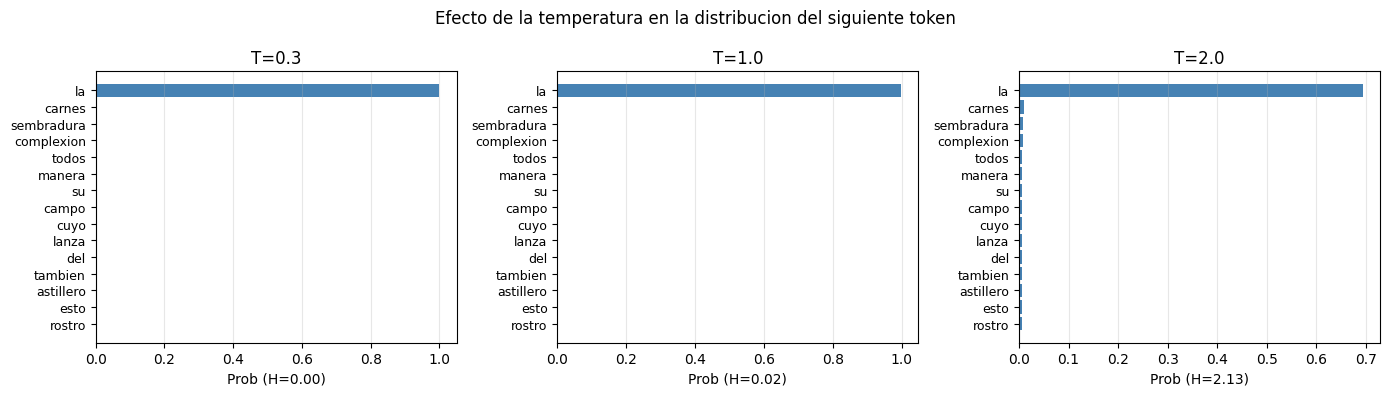

In [23]:
# Efecto de la temperatura en la distribucion del siguiente token
seed_ids = tokenizer.encode('en un lugar de', add_special=False)
x_seed   = tf.constant([seed_ids], dtype=tf.int32)
logits_0 = transformer_lm(x_seed, training=False)[0, -1, :].numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, T in zip(axes, [0.3, 1.0, 2.0]):
    l        = logits_0 / T
    l       -= l.max()
    probs    = np.exp(l); probs /= probs.sum()
    top_idx  = np.argsort(probs)[::-1][:15]
    top_p    = probs[top_idx]
    top_w    = [tokenizer.itos[i] for i in top_idx]
    entropy  = -np.sum(probs * np.log(probs + 1e-10))
    ax.barh(range(15), top_p[::-1], color='steelblue')
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_w[::-1], fontsize=9)
    ax.set_title(f'T={T}')
    ax.set_xlabel(f'Prob (H={entropy:.2f})')
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Efecto de la temperatura en la distribucion del siguiente token', fontsize=12)
plt.tight_layout(); plt.show()

---

## 8. Metricas: Perplejidad y BLEU

**Perplejidad:**
$$\text{PPL} = \exp\!\left(-\frac{1}{T}\sum_{t=1}^{T} \log p_\theta(x_t \mid x_{<t})\right)$$

**BLEU** — media geometrica de precisiones n-grama con brevity penalty:
$$\text{BLEU} = BP \cdot \exp\!\left(\sum_{n=1}^{N} w_n \log p_n\right), \quad BP = \min\!\left(1, e^{1-r/c}\right)$$

Ejemplos de BLEU:

  [Parcialmente correcto]
  Hipotesis : el gato se sienta en la alfombra
  BLEU-4    : 0.0000  BP: 1.0000
  p1=0.714  p2=0.500  p3=0.200  p4=0.000

  [Coincidencia perfecta]
  Hipotesis : el gato esta sentado sobre la alfombra
  BLEU-4    : 1.0000  BP: 1.0000
  p1=1.000  p2=1.000  p3=1.000  p4=1.000

  [Sin solapamiento]
  Hipotesis : un perro corre por el parque
  BLEU-4    : 0.0000  BP: 0.8465
  p1=0.167  p2=0.000  p3=0.000  p4=0.000


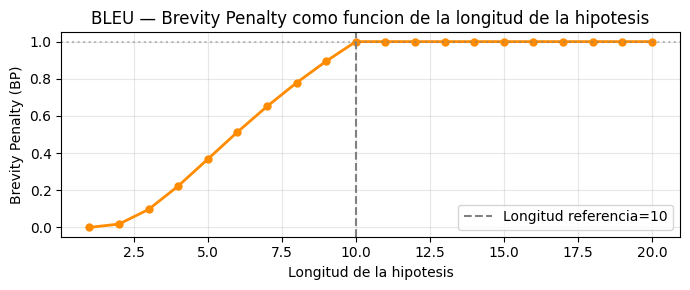

In [24]:
def bleu_score(hypothesis, references, max_n=4):
    """
    Calcula BLEU-N con brevity penalty.

    El 'clip' limita el conteo de cada n-grama al maximo en cualquier
    referencia, evitando inflar el score repitiendo tokens.

    La brevity penalty penaliza hipotesis mas cortas que la referencia.
    """

    def get_ngrams(tokens, n):
        return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))

    def clipped_precision(hyp, refs, n):
        hyp_ng = get_ngrams(hyp, n)
        if not hyp_ng: return 0.0
        max_ref = defaultdict(int)
        for ref in refs:
            for ng, cnt in get_ngrams(ref, n).items():
                max_ref[ng] = max(max_ref[ng], cnt)
        clipped = sum(min(cnt, max_ref[ng]) for ng, cnt in hyp_ng.items())
        return clipped / sum(hyp_ng.values())

    c  = len(hypothesis)
    r  = min(len(ref) for ref in references)
    bp = 1.0 if c > r else math.exp(1 - r/c)

    log_avg = 0.0
    precs   = []
    for n in range(1, max_n+1):
        pn = clipped_precision(hypothesis, references, n)
        precs.append(pn)
        log_avg += (1.0/max_n) * math.log(pn) if pn > 0 else -math.inf

    bleu = bp * math.exp(log_avg) if log_avg != -math.inf else 0.0
    return bleu, precs, bp


casos = [
    ('el gato se sienta en la alfombra',
     ['el gato esta sentado sobre la alfombra', 'hay un gato en la alfombra'],
     'Parcialmente correcto'),
    ('el gato esta sentado sobre la alfombra',
     ['el gato esta sentado sobre la alfombra'],
     'Coincidencia perfecta'),
    ('un perro corre por el parque',
     ['el gato esta sentado sobre la alfombra'],
     'Sin solapamiento'),
]

print('Ejemplos de BLEU:')
print('='*65)
for hyp_t, ref_ts, label in casos:
    hyp  = hyp_t.split()
    refs = [r.split() for r in ref_ts]
    score, precs, bp = bleu_score(hyp, refs)
    print(f'\n  [{label}]')
    print(f'  Hipotesis : {hyp_t}')
    print(f'  BLEU-4    : {score:.4f}  BP: {bp:.4f}')
    print(f'  p1={precs[0]:.3f}  p2={precs[1]:.3f}  p3={precs[2]:.3f}  p4={precs[3]:.3f}')

# Efecto de la brevity penalty
ref_len   = 10
hyp_lens  = range(1, 21)
bps       = [math.exp(1-ref_len/c) if c <= ref_len else 1.0 for c in hyp_lens]

plt.figure(figsize=(7, 3))
plt.plot(list(hyp_lens), bps, color='darkorange', lw=2, marker='o', ms=5)
plt.axvline(ref_len, color='gray', ls='--', label=f'Longitud referencia={ref_len}')
plt.axhline(1.0, color='gray', ls=':', alpha=0.5)
plt.xlabel('Longitud de la hipotesis'); plt.ylabel('Brevity Penalty (BP)')
plt.title('BLEU — Brevity Penalty como funcion de la longitud de la hipotesis')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [25]:
# RESUMEN COMPARATIVO FINAL
tabla = [
    ('N-grama',     'Frecuencias',    'Laplace',     'No',  'No',   'O(V^n)',   'Muy baja'),
    ('Word2Vec',    'Skip-gram NS',   'GradTape TF', 'No',  'Si',   'O(V·K)',   'Baja'),
    ('RNN',         'BPTT',           'Adam+clip',   'Si',  'No',   'O(T·d^2)', 'Media'),
    ('LSTM',        'BPTT+gates',     'Adam+clip',   'Si',  'No',   'O(T·d^2)', 'Media'),
    ('GRU',         'BPTT+gates',     'Adam+clip',   'Si',  'No',   'O(T·d^2)', 'Media'),
    ('Transformer', 'Atencion',       'AdamW+CosDec','Si',  'Si',   'O(T^2·d)', 'Alta'),
]

print('Resumen comparativo de arquitecturas NLP (TensorFlow)')
print('='*95)
print(f'{"Modelo":<15} {"Aprendizaje":<17} {"Truco":<15} {"Ctx":<5} {"Emb":<6} {"Complejidad":<12} {"Capacidad"}')
print('-'*95)
for r in tabla:
    print(f'{r[0]:<15} {r[1]:<17} {r[2]:<15} {r[3]:<5} {r[4]:<6} {r[5]:<12} {r[6]}')

Resumen comparativo de arquitecturas NLP (TensorFlow)
Modelo          Aprendizaje       Truco           Ctx   Emb    Complejidad  Capacidad
-----------------------------------------------------------------------------------------------
N-grama         Frecuencias       Laplace         No    No     O(V^n)       Muy baja
Word2Vec        Skip-gram NS      GradTape TF     No    Si     O(V·K)       Baja
RNN             BPTT              Adam+clip       Si    No     O(T·d^2)     Media
LSTM            BPTT+gates        Adam+clip       Si    No     O(T·d^2)     Media
GRU             BPTT+gates        Adam+clip       Si    No     O(T·d^2)     Media
Transformer     Atencion          AdamW+CosDec    Si    Si     O(T^2·d)     Alta


---

## Conclusiones

**N-gramas**: modelos estadisticos de conteos. No capturan similitud semantica ni dependencias largas. Utiles como baseline.

**Word2Vec (TF)**: `tf.GradientTape` implementa el bucle personalizado de negative sampling. Los embeddings capturan similitud semantica mediante la hipotesis distribucional.

**RNN/LSTM/GRU (Keras)**: `return_sequences=True` es necesario para prediccion token a token. La API `model.compile() + model.fit()` simplifica el entrenamiento estandar. La LSTM resuelve el gradiente que desaparece con actualizacion aditiva de la celda.

**Transformer (Keras)**: Pre-LN da gradientes mas estables. La mascara causal se implementa sumando $-\infty$ antes del softmax. `CosineDecay` + `AdamW` es el estandar moderno.

**Generacion**: temperatura, top-k y nucleus sampling se combinan para controlar coherencia vs. diversidad. La generacion autorregresiva reprocesa toda la secuencia en cada paso (O(T^2)); el KV-Cache la reduce a O(T).

**BLEU**: mide precision de n-gramas con brevity penalty. La brevity penalty evita que hipotesis muy cortas tengan precision artificial alta.

---

## Referencias

- Bengio, Y., et al. (2003). A neural probabilistic language model. *JMLR*, 3.
- Mikolov, T., et al. (2013). Distributed representations of words. *NeurIPS 2013*.
- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*.
- Bahdanau, D., et al. (2015). Neural machine translation by learning to align. *ICLR 2015*.
- Vaswani, A., et al. (2017). Attention is all you need. *NeurIPS 2017*.
- Papineni, K., et al. (2002). BLEU. *ACL 2002*.